# ODMR fitting notebook: reference spectrum -> line centers -> B0, D, Mz

This notebook does the first calibration step for NV vector magnetometry.

Goal:
1. Fit a fully resolved ODMR spectrum with 8 hyperfine-resolved transitions.
2. Extract the 8 ODMR transition centers.
3. Pair left/right transitions by NV axis using the experimentally known assignment:
   - left side order: d1, d2, d3, d4
   - right side order: d4, d3, d2, d1
4. Use those 8 fitted line centers to estimate and then refine:
   - B0 = (Bx, By, Bz)
   - D
   - Mz = (Mz1, Mz2, Mz3, Mz4)

Conventions used here:
- Raw frequency is read in Hz.
- All fitting and Hamiltonian calculations are done in MHz.
- Plot labels may use GHz for readability.

Physical model:
- Each ODMR transition is modeled as a triplet of Lorentzians representing the 14N hyperfine structure.
- The full spectrum is fit globally.
- The fitted 8 transition centers are then used in a reduced spin-1 Hamiltonian fit.

Diamond / frame convention used in this notebook:
- {100} cut diamond
- d1, d2 = axes below the plane
- d3, d4 = axes above the plane
- left-side dip order is imposed from experiment: d1, d2, d3, d4

## 1. Imports and Constants


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import least_squares
from itertools import product
from fit_functions import (normalize_signal, fit_baseline_poly, eval_baseline_poly, detect_8_transition_guesses, residuals_odmr_full, odmr_model_full)

# Constants
# -----------------------------
GAMMA_E_MHZ_PER_MT = 28.02495164   # electron gyromagnetic ratio in MHz/mT
SQRT2_OVER3 = np.sqrt(2.0 / 3.0)
ONE_OVER_SQRT3 = 1.0 / np.sqrt(3.0)

# Spin-1 matrices in the {|+1>, |0>, |-1>} basis
Sx = (1 / np.sqrt(2)) * np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0]
], dtype=float)

Sy = (1 / np.sqrt(2)) * np.array([
    [0, -1j, 0],
    [1j, 0, -1j],
    [0, 1j, 0]
], dtype=complex)

Sz = np.array([
    [1, 0, 0],
    [0, 0, 0],
    [0, 0, -1]
], dtype=float)

Sz2 = Sz @ Sz


# NV axes in the laboratory frame
# Convention fixed to your setup:
# d1,d2 below plane, d3,d4 above plane
# -----------------------------
n_d3 = np.array([ SQRT2_OVER3,  0.0,             ONE_OVER_SQRT3])
n_d2 = np.array([ 0.0,           SQRT2_OVER3,   -ONE_OVER_SQRT3])
n_d4 = np.array([-SQRT2_OVER3,   0.0,             ONE_OVER_SQRT3])
n_d1 = np.array([ 0.0,          -SQRT2_OVER3,   -ONE_OVER_SQRT3])

NV_AXES = {
    "d1": n_d1,
    "d2": n_d2,
    "d3": n_d3,
    "d4": n_d4,
}

# Left-side order imposed by experimental assignment
LEFT_ORDER = ["d1", "d2", "d3", "d4"]
RIGHT_ORDER = ["d4", "d3", "d2", "d1"]  # mirrored around D

print("Using gamma_e =", GAMMA_E_MHZ_PER_MT, "MHz/mT")
print("Left-side order:", LEFT_ORDER)
print("Right-side order:", RIGHT_ORDER)


Using gamma_e = 28.02495164 MHz/mT
Left-side order: ['d1', 'd2', 'd3', 'd4']
Right-side order: ['d4', 'd3', 'd2', 'd1']


## 2. Load ODMR Data from CSV
Load the `ODMR_avg_99-6dBm_0mW.csv` file using pandas and inspect the data structure.

In [27]:

csv_path = "/home/vita/projects/NV_sensing/data/ODMR_avg_99-6dBm_0mW.csv"  
df = pd.read_csv(csv_path, sep=r"\s+")

# Extract frequency and signal data
# Raw frequency is read in Hz
f_hz = df['Frequency']
y_raw = df['Pixel(95-95)']

# All fitting and Hamiltonian calculations are done in MHz
f_mhz = f_hz / 1e6

# Plot labels may use GHz for readability
f_ghz = f_hz / 1e9

df.head()



,Frequency,Pixel(95-95)
0,2.770000e+09,0.077997
1,2.770200e+09,0.077922
2,2.770400e+09,0.077767
3,2.770600e+09,0.077958
4,2.770800e+09,0.078015


## 3. Fit ODMR Data Using fitlorenzo Functions
Apply the fitting functions from fitlorenzo to the loaded ODMR data to obtain fit parameters.

In [28]:
# -----------------------------
# Initial guesses for the global fit
# -----------------------------
y_norm = normalize_signal(y_raw)

# Fit a simple baseline to the normalized data
baseline_coeffs = fit_baseline_poly(f_mhz, y_norm, deg=2)
baseline_guess = eval_baseline_poly(f_mhz, baseline_coeffs)

# Detect 8 transitions
centers_guess, y_smooth, peak_idx, peak_prom = detect_8_transition_guesses(
    f_mhz, y_norm, smooth_window=21, polyorder=3, prominence=0.01
)

print("Initial 8 center guesses [MHz]:")
print(np.round(centers_guess, 3))

# Rough contrast guesses from local dip depths
contrasts_guess = []
for c0 in centers_guess:
    mask = np.abs(f_mhz - c0) < 1.5
    local_depth = np.max(baseline_guess[mask] - y_norm[mask]) if np.any(mask) else 0.01
    contrasts_guess.append(max(local_depth, 0.003))
contrasts_guess = np.array(contrasts_guess)

# Hyperfine and width guesses
delta_hf_guess = 2.16   # MHz, typical for 14N
gamma_guess = 0.8       # MHz FWHM, adjustable

# Hyperfine weights
w_guess = [1.0, 1.0, 1.0]

# Baseline polynomial coefficients
b2_guess, b1_guess, b0_guess = baseline_coeffs

p0 = np.concatenate([
    centers_guess,
    contrasts_guess,
    [delta_hf_guess, gamma_guess],
    w_guess,
    [b2_guess, b1_guess, b0_guess]
])

# Bounds
center_lb = centers_guess - 5.0
center_ub = centers_guess + 5.0

contrast_lb = np.full(8, 0.0)
contrast_ub = np.full(8, 1.0)

lb = np.concatenate([
    center_lb,
    contrast_lb,
    [1.5, 0.1],          # delta_hf, gamma_fwhm
    [0.0, 0.0, 0.0],     # weights
    [-np.inf, -np.inf, 0.0]
])

ub = np.concatenate([
    center_ub,
    contrast_ub,
    [3.0, 5.0],          # delta_hf, gamma_fwhm
    [10.0, 10.0, 10.0],  # weights
    [np.inf, np.inf, 2.0]
])

fit1 = least_squares(
    residuals_odmr_full,
    x0=p0,
    bounds=(lb, ub),
    args=(f_mhz, y_norm),
    method="trf",
    max_nfev=20000,
    verbose=2
)

p_fit = fit1.x
y_fit = odmr_model_full(f_mhz, p_fit)

centers_fit = np.sort(p_fit[0:8])
contrasts_fit = p_fit[8:16]
delta_hf_fit = p_fit[16]
gamma_fit = p_fit[17]

w_minus, w_zero, w_plus = p_fit[18:21]
w_sum = w_minus + w_zero + w_plus
w_minus, w_zero, w_plus = w_minus / w_sum, w_zero / w_sum, w_plus / w_sum

print("\nFitted transition centers [MHz]:")
print(np.round(centers_fit, 6))
print("delta_hf [MHz] =", delta_hf_fit)
print("gamma_FWHM [MHz] =", gamma_fit)
print("hyperfine weights =", (w_minus, w_zero, w_plus))

Initial 8 center guesses [MHz]:
111    2792.2
175    2805.0
421    2854.2
481    2866.2
523    2874.6
578    2885.6
826    2935.2
880    2946.0
Name: Frequency, dtype: float64


ValueError: Initial guess is outside of provided bounds

## 4. Plot Fitted ODMR Data
Plot the original ODMR data and the fitted curve using matplotlib for visual inspection.

NameError: name 'y_fit' is not defined

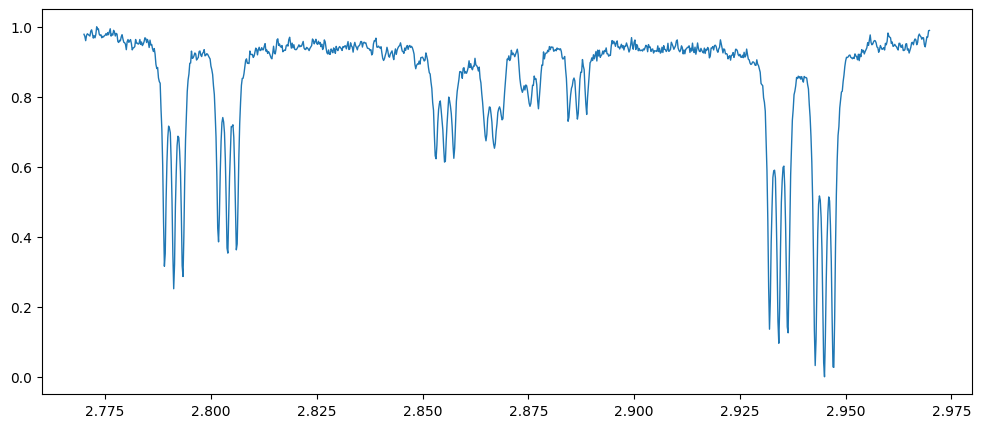

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(f_ghz, y_norm, label="Normalized data", lw=1)
plt.plot(f_ghz, y_fit, label="Global fit", lw=2)

for c in centers_fit:
    plt.axvline(c / 1000.0, color="k", ls="--", alpha=0.25)

plt.xlabel("Frequency (GHz)")
plt.ylabel("Normalized signal")
plt.title("Full ODMR fit: 8 hyperfine-resolved transitions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(f_ghz, y_norm - y_fit, lw=1)
plt.axhline(0, color="k", ls="--")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Residual")
plt.title("Fit residuals")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
pairs = pair_centers_from_8(centers_fit)

summary_rows = []
for axis in ["d1", "d2", "d3", "d4"]:
    f_l, f_u = pairs[axis]
    center_pair = 0.5 * (f_l + f_u)
    splitting = f_u - f_l
    proj_abs_mt = splitting / (2.0 * GAMMA_E_MHZ_PER_MT)

    summary_rows.append({
        "axis": axis,
        "f_left_MHz": f_l,
        "f_right_MHz": f_u,
        "pair_center_MHz": center_pair,
        "splitting_MHz": splitting,
        "|n·B0|_mT_axial_est": proj_abs_mt
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# First estimate of D from the average pair center
D0_guess_mhz = summary_df["pair_center_MHz"].mean()
print("Initial D guess [MHz] =", D0_guess_mhz)

# Mz initial guess from pair centers
Mz0_guess = {
    row["axis"]: row["pair_center_MHz"] - D0_guess_mhz
    for _, row in summary_df.iterrows()
}
print("Initial Mz guesses [MHz] =", Mz0_guess)

NameError: name 'pair_centers_from_8' is not defined

In [ ]:
#INITIAL GESS FOR B
# Geometry matrix in the same axis order used below: d1, d2, d3, d4
N_lab = np.vstack([NV_AXES["d1"], NV_AXES["d2"], NV_AXES["d3"], NV_AXES["d4"]])

proj_abs = summary_df["|n·B0|_mT_axial_est"].to_numpy(dtype=float)

best = None
all_candidates = []

for signs in product([-1.0, 1.0], repeat=4):
    p_signed = np.array(signs) * proj_abs

    # Least-squares solution N_lab * B ≈ p_signed
    B_candidate, *_ = np.linalg.lstsq(N_lab, p_signed, rcond=None)
    residual = p_signed - N_lab @ B_candidate
    ssr = float(residual @ residual)

    all_candidates.append((signs, B_candidate, ssr))

    if best is None or ssr < best[2]:
        best = (signs, B_candidate, ssr)

best_signs, B0_guess_mt, best_ssr = best

print("Best sign pattern:", best_signs)
print("Initial B0 guess [mT] =", B0_guess_mt)
print("Initial SSR =", best_ssr)

NameError: name 'summary_df' is not defined

In [ ]:
#help me functions for H

def make_local_frame(n):
    """
    Construct a right-handed orthonormal frame (ex, ey, ez)
    with ez = n.
    """
    n = np.asarray(n, dtype=float)
    ez = n / np.linalg.norm(n)

    # Choose a reference vector not parallel to ez
    ref = np.array([0.0, 0.0, 1.0])
    if np.abs(np.dot(ref, ez)) > 0.9:
        ref = np.array([1.0, 0.0, 0.0])

    ex = np.cross(ref, ez)
    ex = ex / np.linalg.norm(ex)

    ey = np.cross(ez, ex)
    ey = ey / np.linalg.norm(ey)

    return ex, ey, ez


LOCAL_FRAMES = {axis: make_local_frame(n) for axis, n in NV_AXES.items()}


def B_lab_to_local(B_lab_mt, axis_name):
    ex, ey, ez = LOCAL_FRAMES[axis_name]
    B_lab_mt = np.asarray(B_lab_mt, dtype=float)

    return np.array([
        np.dot(B_lab_mt, ex),
        np.dot(B_lab_mt, ey),
        np.dot(B_lab_mt, ez)
    ], dtype=float)


def hamiltonian_mhz(B_lab_mt, D_mhz, Mz_mhz, axis_name):
    """
    Reduced spin-1 Hamiltonian in MHz:
        H = (D + Mz) Sz^2 + gamma_e * (Bx Sx + By Sy + Bz Sz)
    """
    Bx_loc, By_loc, Bz_loc = B_lab_to_local(B_lab_mt, axis_name)
    zeeman = GAMMA_E_MHZ_PER_MT * (Bx_loc * Sx + By_loc * Sy + Bz_loc * Sz)
    H = (D_mhz + Mz_mhz) * Sz2 + zeeman
    return H


def transition_frequencies_mhz(B_lab_mt, D_mhz, Mz_mhz, axis_name):
    """
    Return lower and upper transition frequencies in MHz.
    """
    H = hamiltonian_mhz(B_lab_mt, D_mhz, Mz_mhz, axis_name)
    evals = np.linalg.eigvalsh(H)
    evals = np.sort(np.real(evals))

    f_lower = evals[1] - evals[0]
    f_upper = evals[2] - evals[0]
    return f_lower, f_upper

In [ ]:
#nonlinear dit for B0, D mz

# Measured frequencies from the spectrum fit
measured = {
    "d1": pairs["d1"],
    "d2": pairs["d2"],
    "d3": pairs["d3"],
    "d4": pairs["d4"],
}

def residuals_operating_point(theta):
    """
    theta = [Bx, By, Bz, D, Mz_d1, Mz_d2, Mz_d3, Mz_d4]
    Units:
    - B in mT
    - D, Mz in MHz
    """
    Bx, By, Bz, D_mhz, Mz_d1, Mz_d2, Mz_d3, Mz_d4 = theta
    B_lab = np.array([Bx, By, Bz], dtype=float)
    Mz_map = {
        "d1": Mz_d1,
        "d2": Mz_d2,
        "d3": Mz_d3,
        "d4": Mz_d4,
    }

    res = []
    for axis in ["d1", "d2", "d3", "d4"]:
        f_l_pred, f_u_pred = transition_frequencies_mhz(B_lab, D_mhz, Mz_map[axis], axis)
        f_l_meas, f_u_meas = measured[axis]

        res.append(f_l_pred - f_l_meas)
        res.append(f_u_pred - f_u_meas)

    return np.array(res, dtype=float)


theta0 = np.array([
    B0_guess_mt[0],
    B0_guess_mt[1],
    B0_guess_mt[2],
    D0_guess_mhz,
    Mz0_guess["d1"],
    Mz0_guess["d2"],
    Mz0_guess["d3"],
    Mz0_guess["d4"],
], dtype=float)

# Loose but physical bounds
lb = np.array([
    -50.0, -50.0, -50.0,   # Bx, By, Bz [mT]
    2800.0,                # D [MHz]
    -20.0, -20.0, -20.0, -20.0  # Mz_i [MHz]
])

ub = np.array([
     50.0,  50.0,  50.0,
    2940.0,
     20.0,  20.0,  20.0,  20.0
])

fit2 = least_squares(
    residuals_operating_point,
    x0=theta0,
    bounds=(lb, ub),
    method="trf",
    max_nfev=20000,
    verbose=2
)

theta_fit = fit2.x
Bx0, By0, Bz0, D_fit_mhz, Mz1_fit, Mz2_fit, Mz3_fit, Mz4_fit = theta_fit

print("\nRefined operating point:")
print(f"B0 [mT] = ({Bx0:.6f}, {By0:.6f}, {Bz0:.6f})")
print(f"D  [MHz] = {D_fit_mhz:.6f}")
print(f"Mz [MHz] = d1:{Mz1_fit:.6f}, d2:{Mz2_fit:.6f}, d3:{Mz3_fit:.6f}, d4:{Mz4_fit:.6f}")
print("Residual norm [MHz] =", np.linalg.norm(fit2.fun))

In [ ]:
#compare measured vs calculated H

Mz_fit_map = {"d1": Mz1_fit, "d2": Mz2_fit, "d3": Mz3_fit, "d4": Mz4_fit}
B_fit = np.array([Bx0, By0, Bz0], dtype=float)

rows = []
for axis in ["d1", "d2", "d3", "d4"]:
    f_l_meas, f_u_meas = measured[axis]
    f_l_pred, f_u_pred = transition_frequencies_mhz(B_fit, D_fit_mhz, Mz_fit_map[axis], axis)

    rows.append({
        "axis": axis,
        "f_left_meas_MHz": f_l_meas,
        "f_left_pred_MHz": f_l_pred,
        "left_err_kHz": 1e3 * (f_l_pred - f_l_meas),
        "f_right_meas_MHz": f_u_meas,
        "f_right_pred_MHz": f_u_pred,
        "right_err_kHz": 1e3 * (f_u_pred - f_u_meas),
        "pair_center_MHz": 0.5 * (f_l_meas + f_u_meas),
        "Mz_fit_MHz": Mz_fit_map[axis]
    })

compare_df = pd.DataFrame(rows)
display(compare_df)

results = {
    "B0_mT": {
        "Bx": float(Bx0),
        "By": float(By0),
        "Bz": float(Bz0),
    },
    "D_MHz": float(D_fit_mhz),
    "Mz_MHz": {
        "d1": float(Mz1_fit),
        "d2": float(Mz2_fit),
        "d3": float(Mz3_fit),
        "d4": float(Mz4_fit),
    },
    "delta_hf_MHz": float(delta_hf_fit),
    "gamma_fwhm_MHz": float(gamma_fit),
    "transition_centers_MHz_sorted": centers_fit.tolist(),
    "pairs_MHz": {
        axis: [float(v[0]), float(v[1])] for axis, v in pairs.items()
    }
}

results_df = pd.DataFrame({
    "parameter": [
        "Bx_mT", "By_mT", "Bz_mT", "D_MHz",
        "Mz_d1_MHz", "Mz_d2_MHz", "Mz_d3_MHz", "Mz_d4_MHz",
        "delta_hf_MHz", "gamma_fwhm_MHz"
    ],
    "value": [
        Bx0, By0, Bz0, D_fit_mhz,
        Mz1_fit, Mz2_fit, Mz3_fit, Mz4_fit,
        delta_hf_fit, gamma_fit
    ]
})

results_df.to_csv("odmr_reference_fit_summary.csv", index=False)
print("Saved: odmr_reference_fit_summary.csv")
display(results_df)